# Practica M23
El objetivo de esta actividad es que efectúes un análisis de clasificación mediante Árboles de decisión que permita desarrollar un modelo predictivo basado en distintas métricas aplicadas a una base de datos grande.
***

**Problema:**   Imagina que eres un investigador médico que recopila datos para un estudio. Has recopilado datos sobre un conjunto de pacientes, todos ellos con la misma enfermedad. Durante su tratamiento, cada paciente ha respondido a uno de los 5 medicamentos, el fármaco A, el fármaco B, el fármaco c, el fármaco X y el Y. 

Parte de tu trabajo consiste en construir un modelo para averiguar qué medicamento podría ser apropiado para un futuro paciente con la misma enfermedad. Los conjuntos de características de este conjunto de datos son la edad, el sexo, la presión arterial y el colesterol de los pacientes, y el objetivo es estudiar el fármaco al que respondió cada paciente. 

Se trata de un ejemplo de clasificación multiclase, y se puede utilizar la parte de entrenamiento del conjunto de datos para construir un árbol de decisión, y luego utilizarlo para predecir la clase de un paciente desconocido, o para prescribirlo a un nuevo paciente.

* ### Cargue la base de datos “drugs.csv” en Python e investigue cómo convertir las variables predictoras cualitativas de esta base a una escala numérica mediante la instrucción “preprocessing.LabelEncoder()”. Por ejemplo, si una variable tiene 3 posibles categorías, deberá cambiar sus resultados a 0, 1 o 2. 

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
df = pd.read_csv('drugs.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
feature_cols = ['Age','Sex', 'BP', 'Cholesterol','Na_to_K']
X = df[feature_cols].values
y = df.Drug

In [4]:
#F = 0, M = 1
cod_sex = LabelEncoder() 
cod_sex.fit(['F','M'])
X[:,1] = cod_sex.transform(X[:,1])

#LOW = 0, NORMAL = 1, HIGH = 2
cod_bp = LabelEncoder()
cod_bp.fit(['LOW','NORMAL','HIGH'])
X[:,2] = cod_bp.transform(X[:,2])

#LOW = 0, NORMAL = 1, HIGH = 2
cod_col = LabelEncoder()
cod_col.fit(['LOW','NORMAL','HIGH'])
X[:,3] = cod_col.transform(X[:,3])


* ### Use el método de Árboles de decisión para generar un modelo predictivo para este problema. Pruebe con los dos criterios vistos en esta lección (Gini y Entropía) y diversos niveles de profundidad. En cada caso elabore un reporte de clasificación detallado. Interprete verbalmente sus indicadores y determine cuál es la mejor opción.

In [5]:
# Creacion de grupos de entrenamiento y prueba

x_train,x_test,y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state = 1)

## Creacion arbol Gini

In [6]:
#Crear objeto de clasificacion del arbol de decision
clf = DecisionTreeClassifier(criterion = 'gini',max_depth = 4)

#Aplicacion del algoritmo de arboles de decision a los grupos de entrenamiento
clf = clf.fit (x_train, y_train)

#Prediccion de la respuesta para el grupo de prueba
y_pred = clf.predict(x_test)

In [7]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix (y_test, y_pred)
cm

array([[ 4,  0,  0,  0,  0],
       [ 2,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

In [8]:
print(clf.classes_)


['drugA' 'drugB' 'drugC' 'drugX' 'drugY']


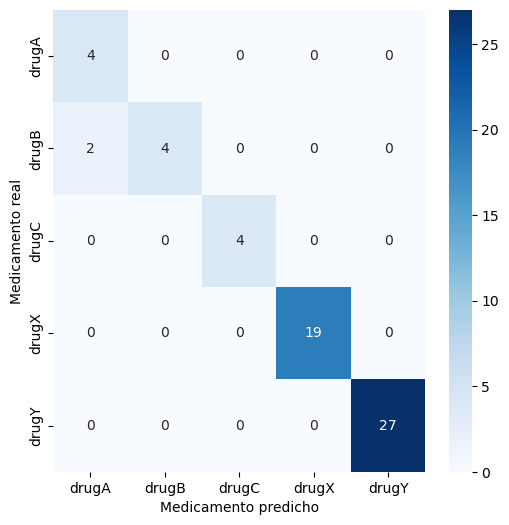

In [9]:
labels = clf.classes_
f, ax = plt.subplots(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Medicamento predicho")
plt.ylabel("Medicamento real")
plt.show()

In [10]:
# Estadistics de desempeño

from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



### Resultados Gini:

La matriz de confusión en este caso se lee por renglón. En el primero corresponde al medicamento A, se tomaron 4 muestras y las 4 se predijeron como ese mismo, por lo que el modelo demuestra que funciona.

Segundo renglón corresponde al medicamento B se tomaron 6 muestras y de ellas 2 se asignaron de forma errónea al medicamento A. Esto indica que hubo cierta confusión del modelo para diferenciar entre los medicamentos A y B en algunos casos. La diferencia entre la decisión de estos medicamentos radica en la edad de los pacientes, por lo que es lo más probable es que el modelo le asigne medicamentos erróneos a personas que están cerca de los 53 años. Un médico deberá evaluar si esto es un error grave o si se puede omitir. 

El resto de medicamento, C, X y Y, tuvieron un desempeño similar que el medicamento A, mostrando resultados satisfactorios y una buena capacidad de predicción para estos medicamentos.

Los indicadores de desempeño muestran que excelentes resultados en todas sus métricas, lo que demuestra de nuevo que este modelo es útil para predecir que medicamento debería tomar cada paciente conforme a sus estudios médicos.  


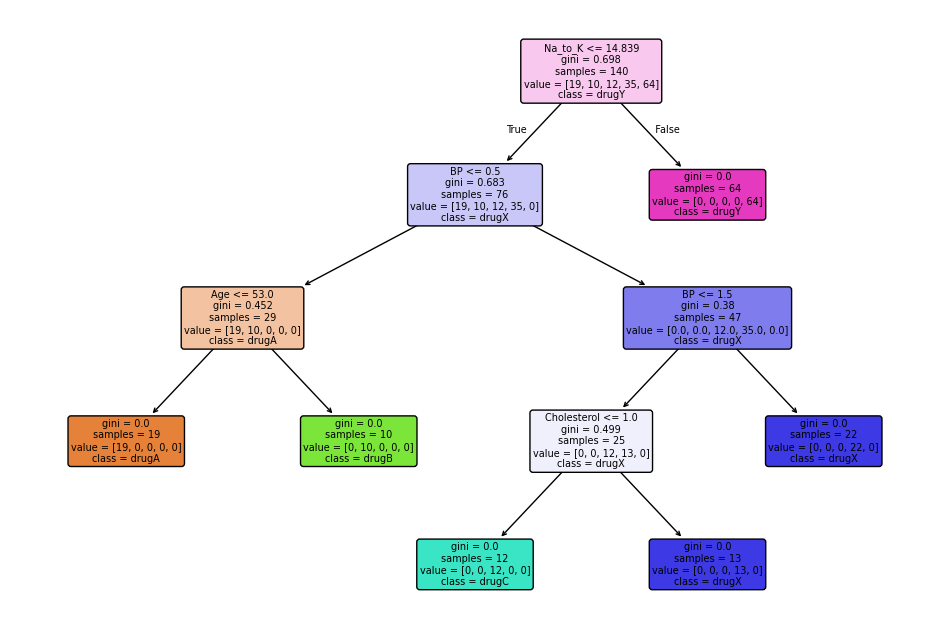

In [11]:
#Creacion arbol gini
from sklearn import tree

plt.figure(figsize=(12,8))

tree.plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=['drugA','drugB','drugC','drugX','drugY'],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.savefig("medicamentos.png", dpi=300)
plt.show()

## Creacion arbol Entropy

In [12]:
#Crear objeto de clasificacion del arbol de decision
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 4)

#Aplicacion del algoritmo de arboles de decision a los grupos de entrenamiento
clf = clf.fit (x_train, y_train)

#Prediccion de la respuesta para el grupo de prueba
y_pred = clf.predict(x_test)

In [13]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



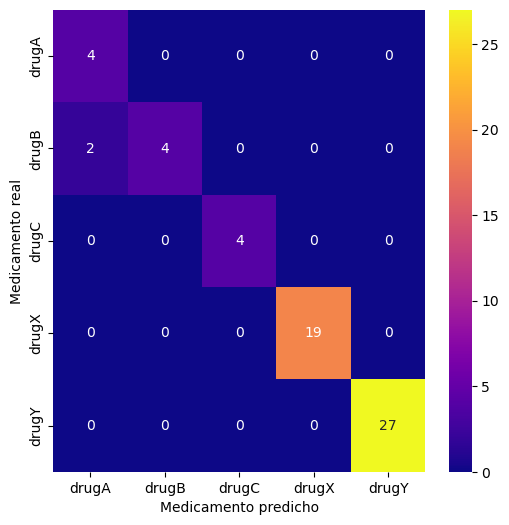

In [14]:
labels = clf.classes_
f, ax = plt.subplots(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='plasma',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Medicamento predicho")
plt.ylabel("Medicamento real")
plt.show()

# Resultados entropy:

Para este caso los resultados de ambos tipos de árbol fue identico, por lo que no hay nada que gregar a su interpetación 

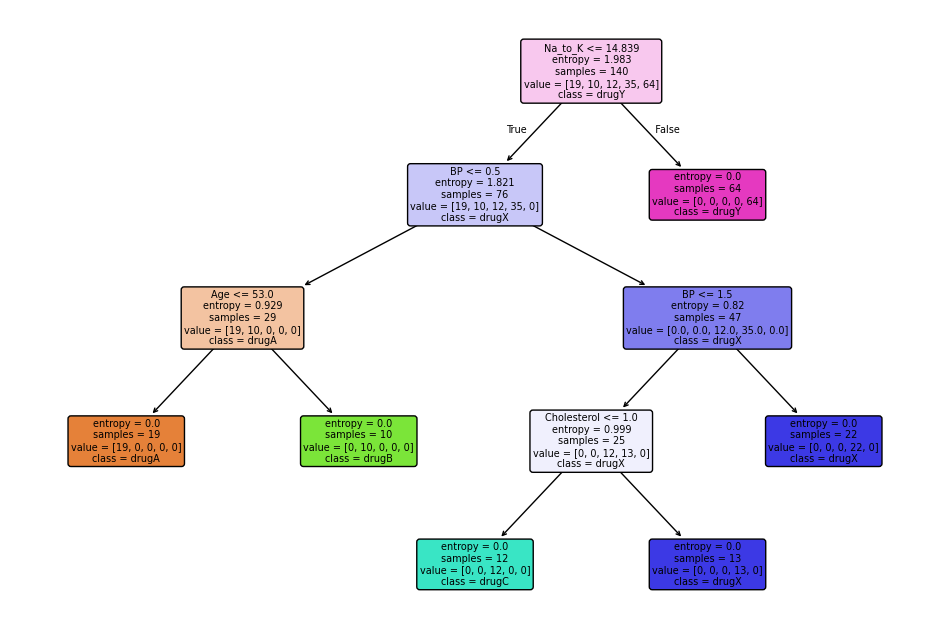

In [15]:
#Creacion arbol entropy
from sklearn import tree

plt.figure(figsize=(12,8))

tree.plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=['drugA','drugB','drugC','drugX','drugY'],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.savefig("medicamentos_entropy.png", dpi=300)
plt.show()

# Interpretación del árbol de decisiones.
### Nivel 1:

* El árbol comienza evaluando la relación Na_to_K.
* Si Na_to_K > 14.839, el modelo recomienda directamente el Medicamento Y.
* Si Na_to_K ≤ 14.839, continúa con la siguiente regla de decisión.

### Nivel 2:

* El modelo evalúa la variable BP (presión arterial).
* Si la presión arterial es LOW, sigue la Ruta 1.
* Si la presión arterial es NORMAL o HIGH, sigue la Ruta 2.

### Nivel 3:

* Ruta 1 (BP = LOW):
    * Si la persona tiene 53 años o menos, se recomienda el Medicamento A.
    * Si la persona tiene más de 53 años, se recomienda el Medicamento B.
* Ruta 2 (BP = NORMAL o HIGH):
    * Si la presión arterial es HIGH, el modelo recomienda directamente el Medicamento X.
    * Si la presión arterial es NORMAL, continúa con el siguiente nivel.

### Nivel 4:

* El modelo evalúa el nivel de colesterol.
* Si el colesterol es LOW o NORMAL, recomienda el Medicamento C.
* Si el colesterol es HIGH, recomienda el Medicamento X.

* ### ¿Qué medicamento recomendaría utilizar para un paciente con los siguientes datos?:

| AGE | SEX | BP   | CHOLESTEROL | NA_TO_K |
|-----|-----|------|-------------|---------|
| 50  | F   | HIGH | NORMAL      | 15.302  |

In [16]:
query = {'Age' : [50],
         'Sex': [0],
         'BP': [2],
         'Cholesterol': [2],
         'Na_to_K': [15.302] 
        }
dfQuery = pd.DataFrame(query)
dfQuery 

,Age,Sex,BP,Cholesterol,Na_to_K
0,50,0,2,2,15.302


In [17]:
medicamento = clf.predict(dfQuery)
print("Medicamento recomendado:" ,medicamento)


Medicamento recomendado: ['drugY']


## Resultado

De acuerdo a ambos árboles, el medicamento recomendado para el paciente es el **Medicameno Y**